In [1]:
suppressMessages(library("rwwa"))
png_res <- 300

nsamp <- 500

In [2]:
cities <- sort(read.csv("cities-in-region.csv")[,1])
countries <- read.csv("../../02_wwa-private/heat-health-impacts/850-cities/00_paper/00_clean-copy/countries-sorted.csv")
cities <- paste0(countries$CNTR_CODE[countries$CNTR_CODE %in% substr(cities,1,2)],"001C")

In [3]:
gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

cov_2026 <- gmst[gmst$year == 2026,"gmst",drop = F]
cov_cf <- data.frame(rbind("pi" = cov_2026 - 1.4,
                           "1976" = cov_2026 - 1.1,
                           "2003" = cov_2026 - 0.6))

# Fit to ERA5 to get approximate return period for 2026

In [39]:
ds_nm <- "era5"
fl <- list.files("ts", pattern = paste0("june_.+",ds_nm), full.names = T)

for (fnm in fl) {
    varnm <- gsub(".+/|_.+","",fnm)
    
    df <- read.csv(fnm)
    df <- merge(gmst, df)

    for (cit in cities) {
        mdl <- fit_ns("gev", "shift", data = df, covnm = "gmst", varnm = cit, lower = F)

        res_fnm <- paste0("res/res_",varnm,"_",cit,"_", ds_nm, "_ev.csv")
        if (!file.exists(res_fnm)) {
            res <- boot_ci(mdl, cov_f = cov_2026, cov_cf = cov_cf, nsamp = 1000)
            write.csv(res, res_fnm)
        }
    }
}

# Fit to all datasets with fixed RP

## List return periods in ERA5

### Table for doc

In [52]:
rp <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- signif(read.csv(fnm, row.names = "X")["return_period",], 3)
               paste0(r[1], " (", r[2],", ", r[3], ")")
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]

In [53]:
ev <- sapply(c("tx3x", "tn3x"), function(varnm) {
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- signif(read.csv(fnm, row.names = "X")["event_magnitude","est"], 4)
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]

In [54]:
tbl <- data.frame("ev_tx3x" = ev[,"tx3x"], "rp_tx3x-june" = rp[,"tx3x-june"], "rp_tx3x" = rp[,"tx3x"],
                  "ev_tn3x" = ev[,"tn3x"], "rp_tn3x-june" = rp[,"tn3x-june"], "rp_tn3x" = rp[,"tn3x"])

write.csv(tbl, "tbl-per-capital_ev.csv")
tbl

,ev_tx3x,rp_tx3x.june,rp_tx3x,ev_tn3x,rp_tn3x.june,rp_tn3x
,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
NO001C,25.84,"4.36 (2.11, 11.6)","1.66 (1.23, 2.42)",15.88,"8.32 (4.3, 29)","1.33 (1.1, 2.09)"
SE001C,28.07,"84.2 (19.3, Inf)","4.84 (2.9, 11.2)",18.45,"38 (12.3, 2700)","2 (1.37, 3.55)"
DK001C,29.27,"37.5 (7.69, Inf)","3.88 (1.9, 8.53)",19.40,"161 (43.8, Inf)","5.29 (2.77, 15.5)"
UK001C,32.73,"65.5 (21.5, Inf)","11.2 (5.45, 35.6)",21.07,"331 (64.9, Inf)","138 (26.8, Inf)"
IE001C,25.37,"145 (32.9, Inf)","14.1 (5.43, 46.9)",15.76,"9.8 (5.37, 48.7)","2.06 (1.37, 3.43)"
FR001C,38.08,"188 (44.9, Inf)","19.4 (7.26, 78.1)",25.57,"213 (48.1, 9.01e+14)","247 (55, Inf)"
BE001C,35.81,"192 (37.7, Inf)","17.3 (7.07, 103)",23.71,"1130 (103, Inf)","165 (45.4, Inf)"
NL001C,32.21,"119 (24.9, Inf)","6.86 (3.13, 55.3)",20.85,"238 (36.8, Inf)","9.48 (3.87, 31.1)"
LU001C,36.36,"319 (49.5, Inf)","24 (10.7, 103)",23.07,"250 (54.9, Inf)","53.8 (21.4, 723)"


In [55]:
tbl_old <- read.csv("tbl-per-capital_ev_26-06-23.csv", row.names = "X")

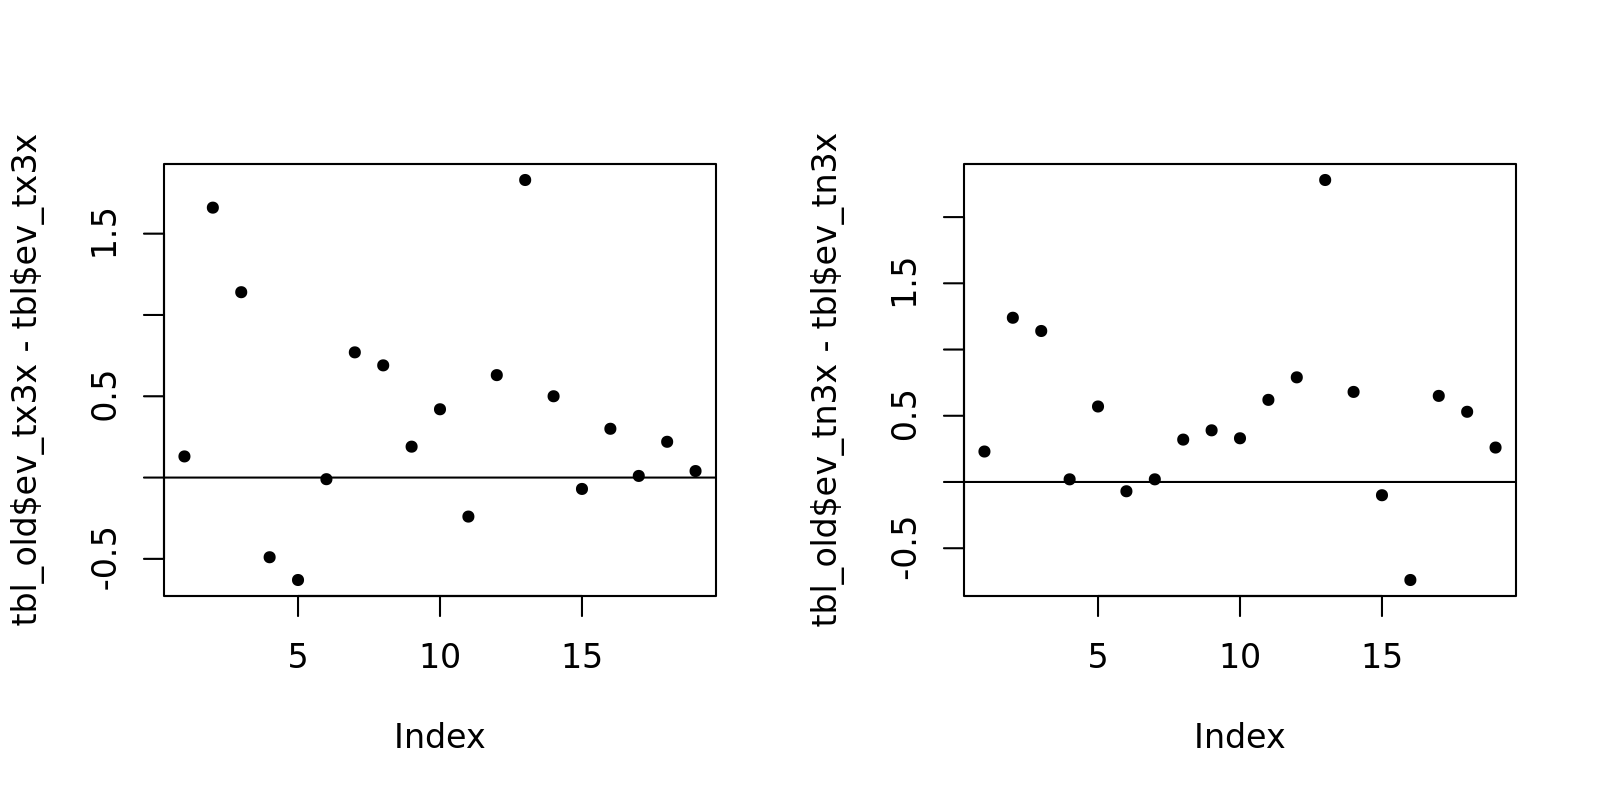

In [56]:
prep_window(c(1,2))

plot(tbl_old$ev_tx3x - tbl$ev_tx3x); abline(h = 0)
plot(tbl_old$ev_tn3x - tbl$ev_tn3x); abline(h = 0)

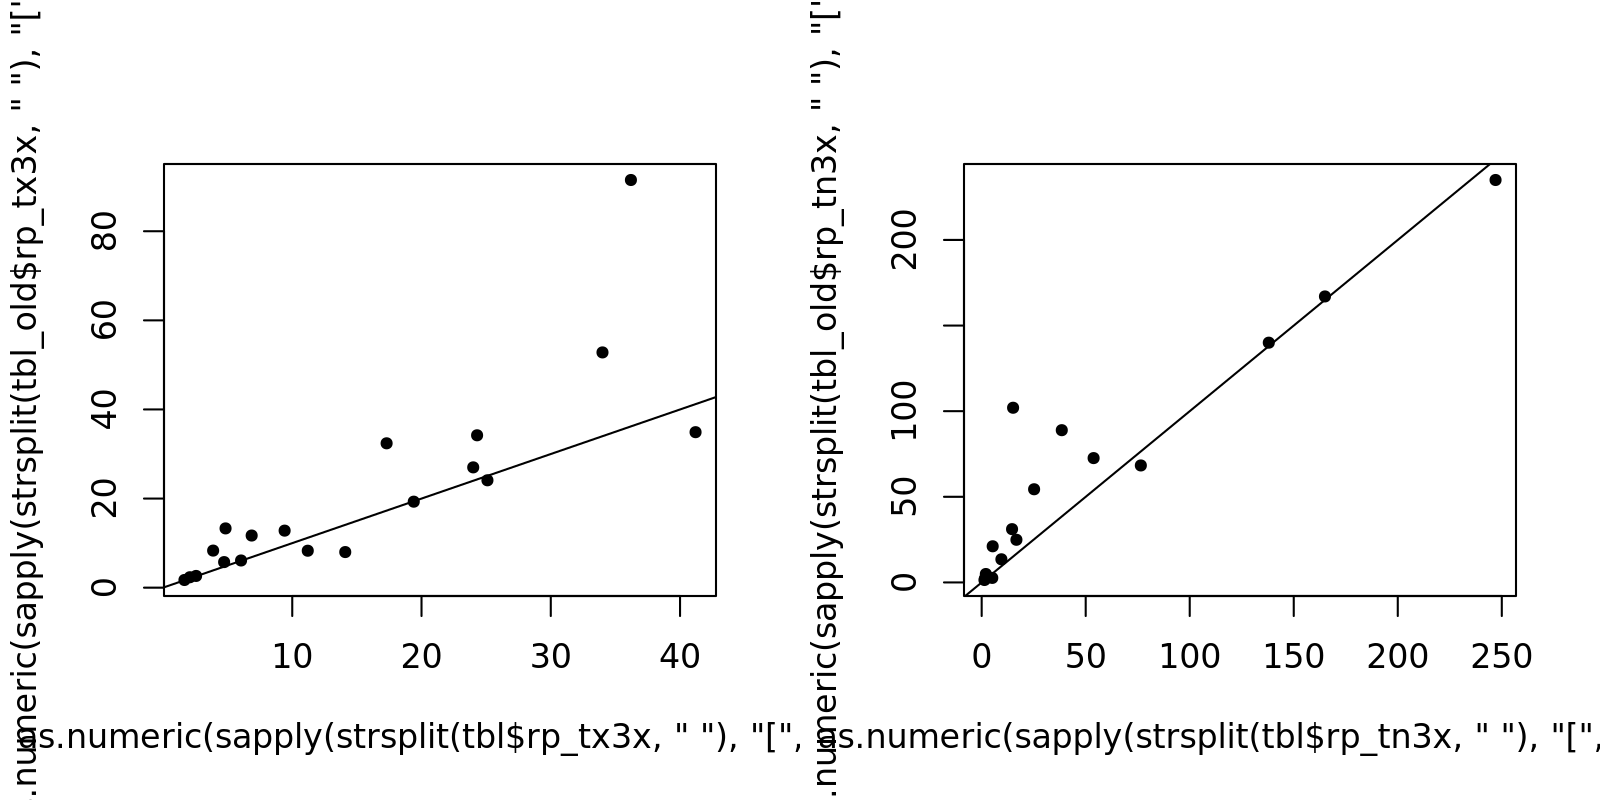

In [57]:
prep_window(c(1,2))

plot(as.numeric(sapply(strsplit(tbl$rp_tx3x, " "), "[", 1)), as.numeric(sapply(strsplit(tbl_old$rp_tx3x, " "), "[", 1))); abline(0,1)
plot(as.numeric(sapply(strsplit(tbl$rp_tn3x, " "), "[", 1)), as.numeric(sapply(strsplit(tbl_old$rp_tn3x, " "), "[", 1))); abline(0,1)

In [58]:
tbl_old["CZ001C",]

,ev_tx3x,rp_tx3x.june,rp_tx3x,ev_tn3x,rp_tn3x.june,rp_tn3x
,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
CZ001C,39.3,"1080 (110, Inf)","91.5 (32.2, 3720)",24.13,"1320 (120, Inf)","102 (35.9, 1880)"


In [59]:
tbl["CZ001C",]

,ev_tx3x,rp_tx3x.june,rp_tx3x,ev_tn3x,rp_tn3x.june,rp_tn3x
,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
CZ001C,37.47,"484 (65.4, Inf)","36.2 (16.6, 197)",21.85,"318 (52.6, Inf)","15.1 (7.21, 43.2)"


### Get RP for fitting

In [60]:
rp_ref <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               read.csv(fnm, row.names = "X")["return_period","est"]
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]

rp_ref <- ceiling(rp_ref)
rp_ref[rp_ref > 100] <- 100

In [61]:
rp_org <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    res <- c(sapply(list.files("res_260623", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               read.csv(fnm, row.names = "X")["return_period","est"]
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]

rp_org <- ceiling(rp_org)
rp_org[rp_org > 100] <- 100

### Get fitted trend

In [62]:
varnm <- "tx3x"
fl <- list.files("ts", pattern = varnm, full.names = T)

for (fnm in fl) {
    varnm <- gsub(".+/|_.+","",fnm)
    ds_nm <- gsub(".+_|.csv","",fnm)
    
    df <- read.csv(fnm)
    df <- df[,colSums(is.na(df)) == 0] # remove out-of-domain cities
    df <- merge(gmst, df)

    for (cit in cities) {

        # no need to refit all datasets if the RP was more than 100 years
        if ((ds_nm != "era5") & (rp_org[cit,varnm] == 100)) next
        
        mdl <- fit_ns("gev", "shift", data = df, covnm = "gmst", varnm = cit, lower = F)
        rp <- rp_ref[cit,varnm]

        
        erl <- eff_return_level(mdl, rp = rp, fixed_cov = cov_2026)

        mdl <- fit_ns("gev", "shift", data = df, covnm = "gmst", varnm = cit, lower = F, ev = erl, ev_year = 2026)

        res_fnm <- paste0("res/res_",varnm,"_",cit,"_", ds_nm, "_fixed-rp.csv")
        if (!file.exists(res_fnm)) {
            res <- boot_ci(mdl, cov_f = cov_2026, cov_cf = cov_cf, nsamp = nsamp)
            write.csv(res, res_fnm)
        }
        
        # create & save trend plot
        tp_fnm <- paste0("trendplots/trendplots_",varnm,"_",cit,"_", ds_nm, ".png")
        if (!file.exists(tp_fnm)) {
            png(tp_fnm, h = png_res, w = png_res * 3 * 1.5); {
                prep_window(c(1,3), oma = c(0,0,1,0))
                ylim <- range(pretty(df[,cit])) + c(0,5)
                
                plot_trend(mdl, ylim = ylim, ev_year = 2026, ev = erl)
                plot_covtrend(mdl, "gmst", ylim = ylim, ev_x = 0, ev = erl)
                plot_returnlevels(mdl, cov_f = cov_2026, cov_cf = cov_cf["2003",,drop = F], nsamp = 50, ylim = ylim, legend_pos = "bottomright")
    
                mtext(paste0(cit, " ", varnm, " - ", ds_nm), outer = T, side = 3, font = 2, line = -2)
            }; dev.off()
        }
    }
}

### Compile results

In [18]:
varnm <- "tx3x"
for (ds_nm in c("era5", "cpc", "berkeley", "eobs")) {
    fl <- list.files("res", pattern = paste0(varnm,"_.+",ds_nm,"_fixed-rp"), full.names = T)
}

In [49]:
res <- t(sapply(list.files("res", pattern = "fixed-rp", full.names = T), function(fnm) {
    res <- read.csv(fnm, row.names = "X")
    unlist(sapply(rownames(res), function(rnm) setNames(res[rnm,], c("est", "lower", "upper")), simplify = F))
}, simplify = T))
rownames(res) <- gsub("res/res_|_fixed-rp.csv","",rownames(res))

In [51]:
write.csv(res, "res-per-capital_all-datasets.csv")

### Synthesise results

In [27]:
res <- read.csv("res-per-capital_all-datasets.csv", row.names = "X")

In [62]:
cnm <- "PR_2003" # dI_abs_2003

synth <- data.frame(t(sapply(unique(gsub("001C.+","",rownames(res))), function(grp) {
# for (grp in unique(gsub("001C.+","",rownames(res)))) {
    obs_in <- res[grepl(grp, rownames(res)), grepl(cnm, colnames(res))]
    if (!any(is.finite(obs_in[,1]))) {
        setNames(rep(NA, 5), c("est", "lower", "upper", "lowest_f", "highest_f"))
    } else {
        if (grepl("PR", cnm)) {
            obs_in <- infer_infinite(obs_in)
            stype <- "PR"
        } else {
            stype <- "abs"
        }
        obs_rng <- setNames(range(obs_in[is.finite(unlist(obs_in)) & obs_in > 0]), c("lowest_f", "highest_f"))
        c(unlist(synthesis(obs_in, obs_in, synth_type = "PR")$df[5,3:5]), obs_rng)
    }
# }
    
})))
colnames(synth) <- paste0(cnm,".",colnames(synth))
rownames(synth) <- paste0(rownames(synth), "001C")
write.csv(synth, paste0("obs-synth_",cnm,".csv"))

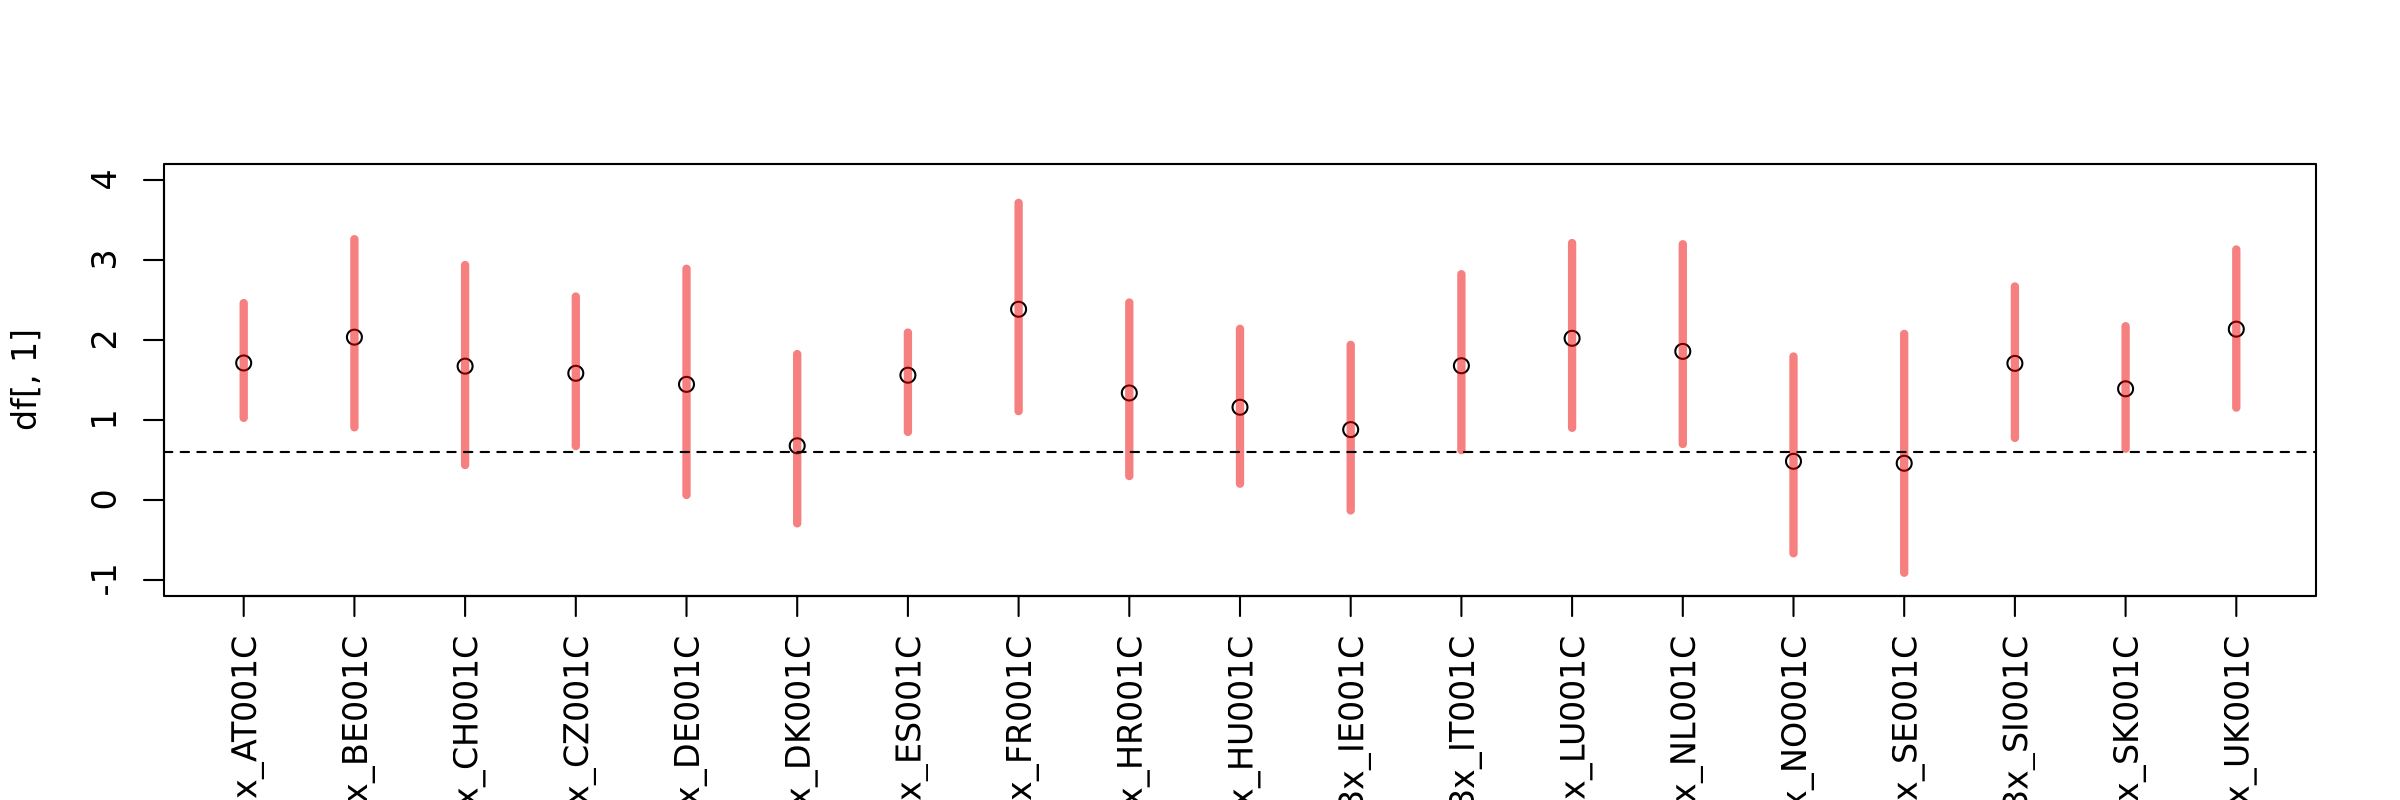

In [ ]:
df <- synth[grepl("tx3x_", rownames(synth)),]

plot(df[,1], ylim = c(-1,4), xaxt = "n", xlab = "")
segments(x0 = 1:19, y0 = df[,2], y1 = df[,3], lwd = 4, col = adjustcolor("red2", 0.5))
abline(h = -cov_cf["2003",], col = "black", lty = 2)
axis(1, at = 1:19, labels = rownames(df), las = 2)

## Tables for doc

In [51]:
resnm <- "PR_2003"

synth <- read.csv(paste0("obs-synth_",resnm,".csv"), row.names = "X")

tbl <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    df <- synth[grepl(paste0(varnm, "_"), rownames(synth)),]
    sapply(1:nrow(df), function(i) {
        if (grepl("PR", resnm)) {
            r <- signif(df[i,], 3)
        } else {
            r <- round(df[i,], 1)
        }
        
        r[r > 1000000] <- ">1m"
        paste0(r[1], " (", r[2],", ", r[3], ")")
    })
}, simplify = T)
colnames(tbl) <- paste0(resnm,"_",colnames(tbl))
rownames(tbl) <- gsub(".+_","",rownames(synth))[1:19]

write.csv(tbl, paste0("tbl-per-capital_",gsub("_","-",resnm),".csv"))
tbl

,PR_2003_tx3x,PR_2003_tx3x-june,PR_2003_tn3x,PR_2003_tn3x-june
AT001C,"13.1 (1.29, 1590)","11200 (0.000182, >1m)","1110 (0.0326, >1m)","2580 (0.000579, >1m)"
BE001C,"25.7 (1.79, 23400)","66.3 (0, >1m)","26.2 (0.223, 87600)","53.5 (0.0436, >1m)"
CH001C,"10.7 (1.33, 686)","93.5 (0.072, >1m)","62.4 (0.0434, >1m)","1680 (0.00158, >1m)"
CZ001C,"8.19 (1.35, 699)","25.2 (1.31, 13800)","4.71 (0, 221)","9.42 (0.76, 796)"
DE001C,"6.36 (1.86, 354)","97.4 (0.0528, >1m)","82.9 (0.116, >1m)","78.6 (0.0687, >1m)"
DK001C,"21.5 (0.0476, >1m)","5.72 (0.11, 17800)","3.86 (0.253, 152)","10.9 (0, 90200)"
ES001C,"12.9 (1.79, 699)","12.1 (0.801, 357)","7.53 (1.37, 59.4)","125 (2.31, 228000)"
FR001C,"12.2 (2.36, 1520)","39.1 (0.145, 242000)","8.56 (1.44, 270)","7.26 (1.31, 444)"
HR001C,"2.97 (1.39, 13.4)","69.4 (0.243, 796000)","7.45 (1.03, 199)","NA (NA, NA)"
HU001C,"4.34 (1.46, 1670)","72.7 (0.0521, >1m)",">1m (1.03e-19, >1m)","111 (0.819, >1m)"


In [110]:
df <- merge(merge(read.csv("tbl-per-capital_ev.csv"),
            read.csv("tbl-per-capital_dI-abs-2003.csv")),
      read.csv("tbl-per-capital_PR-2003.csv"))
rownames(df) <- df$X
df <- df[,-1]

In [112]:
df[,grepl("tx3x", colnames(df))]

,ev_tx3x,rp_tx3x.june,rp_tx3x,dI_abs_2003_tx3x,dI_abs_2003_tx3x.june,PR_2003_tx3x,PR_2003_tx3x.june
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AT001C,38.98,"712 (83.4, Inf)","52.8 (19.5, Inf)","13.1 (1.3, 1595)","11232.6 (0, >1m)","13.1 (1.29, 1590)","11200 (0.000182, >1m)"
BE001C,36.58,"340 (50.8, Inf)","32.4 (11.6, 368)","25.7 (1.8, 23351.9)","66.3 (0, >1m)","25.7 (1.79, 23400)","66.3 (0, >1m)"
CH001C,34.50,"77.7 (25.3, Inf)","12.8 (5.65, 43.9)","10.7 (1.3, 686.5)","93.5 (0.1, >1m)","10.7 (1.33, 686)","93.5 (0.072, >1m)"
CZ001C,39.30,"1080 (110, Inf)","91.5 (32.2, 3720)","8.2 (1.4, 699.2)","25.2 (1.3, 13819.1)","8.19 (1.35, 699)","25.2 (1.31, 13800)"
DE001C,37.99,"609 (70.3, Inf)","34.9 (12.4, 240)","6.4 (1.9, 353.9)","97.4 (0.1, >1m)","6.36 (1.86, 354)","97.4 (0.0528, >1m)"
DK001C,30.41,"149 (23, Inf)","8.32 (3.32, 34.9)","21.5 (0, >1m)","5.7 (0.1, 17805.6)","21.5 (0.0476, >1m)","5.72 (0.11, 17800)"
ES001C,39.07,"7.31 (3.53, 22)","2.63 (1.79, 5.19)","12.9 (1.8, 698.9)","12.1 (0.8, 357.2)","12.9 (1.79, 699)","12.1 (0.801, 357)"
FR001C,38.07,"187 (44.7, Inf)","19.3 (7.21, 77.7)","12.2 (2.4, 1519.1)","39.1 (0.1, 241905.9)","12.2 (2.36, 1520)","39.1 (0.145, 242000)"
HR001C,35.85,"7.54 (3.59, 25.7)","2.34 (1.53, 3.83)","3 (1.4, 13.4)","69.4 (0.2, 795720.9)","2.97 (1.39, 13.4)","69.4 (0.243, 796000)"
